In [1]:
%load_ext autoreload
%autoreload 2
import SepVector
from fwix import CudaOperator
from fwix import CudaWEM
from pyVector import superVector
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt


/home/users/arustam/miniconda3/envs/fwix/lib/python3.11/site-packages/numpy/_core/getlimits.py:558: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/users/arustam/miniconda3/envs/fwix/lib/python3.11/site-packages/numpy/_core/getlimits.py:90: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/users/arustam/miniconda3/envs/fwix/lib/python3.11/site-packages/numpy/_core/getlimits.py:558: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/users/arustam/miniconda3/envs/fwix/lib/python3.11/site-packages/numpy/_core/getlimits.py:90: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
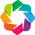

In [2]:
import holoviews as hv 
hv.extension('bokeh')
hv.output(widget_location='bottom')

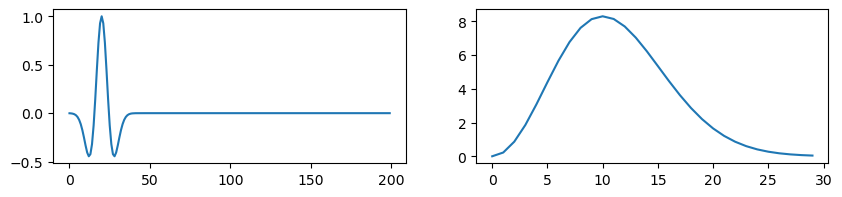

In [3]:
def ricker_wavelet(frequency, Nt, dt, t0=0):
    t = np.linspace(0, (Nt-1)*dt, Nt)
    t_shifted = t - t0
    ricker = (1 - 2 * (np.pi ** 2) * (frequency ** 2) * (t_shifted ** 2)) * np.exp(-(np.pi ** 2) * (frequency ** 2) * (t_shifted ** 2))
    return ricker

# Parameters
frequency = 5  # Ricker wavelet central frequency
Nt = 200    # Length of the wavelet in seconds
dt = 0.01      # Time sampling interval
t0 = 0.2

# Generate Ricker wavelet
wavelet = ricker_wavelet(frequency, Nt, dt, t0=t0)
W = np.fft.fft(wavelet).astype(np.complex64)

dfreq = 1/(Nt*dt)
of = 0.1
maxf = 30.
nf = int((maxf-of) / dfreq)

nf = 30
nz = 50

f, a = plt.subplots(1,2, figsize=[10,2])
a[0].plot(wavelet, label='Ricker Wavelet')
a[1].plot(np.abs(W[int(of/dfreq):nf]), label="Spectrue")

In [4]:
nf

30

In [5]:
import SepVector
import pyVector as Vec
import numpy as np

# --- 1. Define Dimensions (From your snippet) ---
nx = 100; dx = 0.01; ox = 0.0
ny = 2; dy = 0.01; oy = 0.0
dz = 0.01; oz = 0.0


ns = 10
npartitions = 30
NUM_FREQ_SPLITS = 30
ns_per_part = int(ns * NUM_FREQ_SPLITS/npartitions)
print(ns_per_part)

# --- 2. Create Monolithic Models (Your provided setup) ---
# Axes order in SepVector constructor is [Axis1, Axis2, Axis3, Axis4] (Fastest to Slowest)
# Here: 1=X, 2=Y, 3=F, 4=Z
slow = SepVector.getSepVector(ns=[nx,ny,nf,nz], ds=[dx, dy, dfreq, dz], os=[ox, oy, of, oz], storage='dataComplex')

# Fill data (Your logic)
slow[:] = 1.0 + 0j
# Note: In Numpy view of SepVector (C-Order), shape is (n4, n3, n2, n1) -> (nz, nf, ny, nx)
slow_arr = slow.getNdArray() 
slow_arr[nz-5:, ...] = 2.0 + 0j # Modify bottom layer

# Density
den = slow.clone()
den.set(1.0 + 0j)

# --- 3. Split into SuperVector of SuperVectors ---
# Structure: Global_SV -> [ Band0_SV, Band1_SV, ... ]
#            Band0_SV  -> [ Slow0, Den0 ]

band_supervectors = []
n_band_samples = nf // NUM_FREQ_SPLITS

for i in range(NUM_FREQ_SPLITS):
    
    # A. Calculate Indices and Offsets
    idx_start = i * n_band_samples
    # Handle remainder for the last band
    idx_end = nf if i == NUM_FREQ_SPLITS - 1 else idx_start + n_band_samples
    current_nf = idx_end - idx_start
    
    # Calculate new frequency origin for this band
    current_of = of + (idx_start * dfreq)
    
    # B. Create Band Containers
    # We maintain the same X, Y, Z geometry, only F changes (Axis 3)
    # ns list corresponds to [nx, ny, nf, nz]
    band_ns = [nx, ny, current_nf, nz]
    band_ds = [dx, dy, dfreq, dz]
    band_os = [ox, oy, current_of, oz]
    
    s_band = SepVector.getSepVector(ns=band_ns, ds=band_ds, os=band_os, storage='dataComplex')
    d_band = SepVector.getSepVector(ns=band_ns, ds=band_ds, os=band_os, storage='dataComplex')
    
    # C. Fill Data (Slicing)
    # Numpy View Shape is (nz, nf, ny, nx)
    # Frequency is index 1
    s_band.getNdArray()[:] = slow_arr[:, idx_start:idx_end, :, :]
    d_band.getNdArray()[:] = den.getNdArray()[:, idx_start:idx_end, :, :]
    
    # D. Create Mini-SuperVector [Slow, Den]
    band_sv = Vec.superVector(s_band, d_band)
    band_supervectors.append(band_sv)

# --- 4. Create Final Model ---
# This is the object you pass to FWIXmodeling or FWIXProblem
model = Vec.superVector(*band_supervectors)

print(f"Model created with {len(model.vecs)} frequency bands.")
print(f"Band 0 shape: {model.vecs[0].vecs[0].getNdArray().shape}")

n_src_traces = ns
src_traces = SepVector.getSepVector(ns=[nf, n_src_traces],ds=[dfreq, 1],os=[1, 0], storage='dataComplex')
n_rec_traces = nx * ny * ns
rec_traces = SepVector.getSepVector(ns=[nf, n_rec_traces],ds=[dfreq, 1],os=[1, 0], storage='dataComplex')

10
Model created with 30 frequency bands.
Band 0 shape: (50, 1, 2, 100)


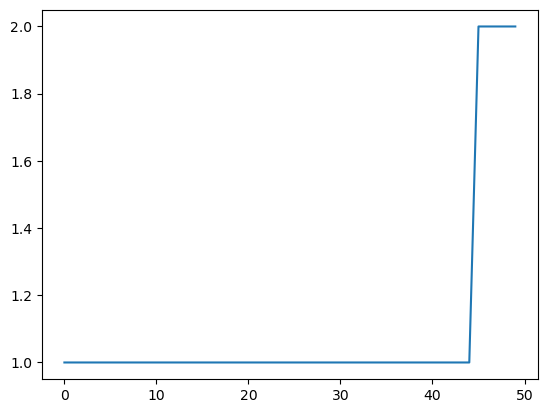

In [6]:
plt.plot(slow[:,0,0,0].real)

In [7]:
n_rec_traces

2000

In [8]:
sx = np.linspace(0, (nx-1)*dx, n_src_traces).astype(np.float32) 
sy = np.linspace(0, (ny-1)*dy, n_src_traces).astype(np.float32) 
sz = np.linspace(0, (nz-1)*dz, n_src_traces).astype(np.float32) * 0 + dz
s_ids = np.linspace(0, ns-1, ns).astype(int)

rx, ry = np.meshgrid(np.linspace(0, (nx-1)*dx, nx), np.linspace(0, (ny-1)*dy, ny))
r_ids = s_ids.repeat(rx.size)
rx = np.tile(rx.flatten(), ns)
ry = np.tile(ry.flatten(), ns)
rz = np.zeros(rx.size) + (nz-1)*dz*0

In [9]:
s_ids

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [10]:
rx.size

2000

In [11]:
import genericIO
import os 

nbatches = [1, 1]
look = 2

par = {
    "nref" : 3,
    "eps" : 0.01,
    "taperx" : 0,
    "tapery" : 0,
    "padx" : nx,
    "pady" : ny,
    "ginsu_x" : 10*dx,
    "ginsu_y" : 10*dy,
    "ref_look_ahead" : look,
    "compress_rate" : 8.,
    "wflds_to_store" : 4,
    "wfld_path" : os.environ["SCRATCH"],
}
prop_par = genericIO.pythonParams(par)

geometry = {
    "sx" : sx, "sy" : sy, "sz" : sz, "s_ids" : s_ids.astype(np.int32),
    "rx" : rx, "ry" : ry, "rz" : rz, "r_ids" : r_ids.astype(np.int32),
}

In [12]:
src_traces

complexVector
Axis 1: n=30	o=1.000000	d=0.500000
Axis 2: n=10	o=0.000000	d=1.000000

In [13]:
len(geometry['sx'])

10

In [14]:
for i in range(n_src_traces):
    src_traces[i, :] = W[:nf]

In [15]:
norm = rec_traces.norm()

In [16]:
import pandas as pd
import SepVector
import numpy as np

n_band = nf // NUM_FREQ_SPLITS

dfs = []
dffs = []
# --- 2. Iterate Over Frequency Bands ---
for freq_id in range(NUM_FREQ_SPLITS):
    
    # A. Calculate Slice Indices
    idx_start = freq_id * n_band
    idx_end = idx_start + n_band
    
    # Handle remainder for the last band if not perfectly divisible
    if freq_id == NUM_FREQ_SPLITS - 1:
        idx_end = nf
        n_current = idx_end - idx_start
    else:
        n_current = n_band

    # B. Slice the Wavelet Data
    # w_slice is the specific frequency content for this band
    w_slice = W[idx_start : idx_end]
    
    # C. Update Physical Origin (o)
    # The new origin is the original origin + offset
    current_os = of + (idx_start * dfreq)
    
    # D. Create SepVectors for this Band
    band_wavelets = []
    band_waves = []
    for i in range(ns):
        vec = SepVector.getSepVector(
            ns=[n_current], 
            ds=[dfreq], 
            os=[current_os], 
            storage='dataComplex'
        )
        vec[:] = w_slice[:]
        band_wavelets.append(vec)
        band_waves.append(w_slice.view(np.float32))
        
    # E. Create DataFrame for this Band
    band_df = pd.DataFrame({
        'uniqueshots': s_ids.tolist(),
        'data': band_wavelets,
        'freq_band_id': freq_id  # Add the ID for the lookup
    })
    band_dff = pd.DataFrame({
            'uniqueshots': s_ids.tolist(),
            'data': band_waves,
            'freq_band_id': freq_id,  # Add the ID for the lookup
            'trace_origin' : current_os
        })
    
    dfs.append(band_df)
    dffs.append(band_dff)

# --- 3. Concatenate and Sort ---
wavelet_df = pd.concat(dfs, ignore_index=True)
wavelet_dff = pd.concat(dffs, ignore_index=True)

# Important: Sort by (Freq, Shot) to match the modeling loop order
wavelet_df = wavelet_df.sort_values(['freq_band_id', 'uniqueshots'])

wavelet_dff.to_parquet(os.environ['SCRATCH'] + '/test/wave.pq')

print(f"Total Wavelet Rows: {len(wavelet_df)} (out of {ns*NUM_FREQ_SPLITS})")
print(f"Samples per Wavelet (Band 0): {wavelet_df.iloc[0]['data'].getHyper().axes[0].n}")

Total Wavelet Rows: 300 (out of 300)
Samples per Wavelet (Band 0): 1


In [17]:
wavelet_df

,uniqueshots,data,freq_band_id
0,0,complexVector\nAxis 1: n=1\to=0.100000\td=0.50...,0
1,1,complexVector\nAxis 1: n=1\to=0.100000\td=0.50...,0
2,2,complexVector\nAxis 1: n=1\to=0.100000\td=0.50...,0
3,3,complexVector\nAxis 1: n=1\to=0.100000\td=0.50...,0
4,4,complexVector\nAxis 1: n=1\to=0.100000\td=0.50...,0
...,...,...,...
295,5,complexVector\nAxis 1: n=1\to=14.600000\td=0.5...,29
296,6,complexVector\nAxis 1: n=1\to=14.600000\td=0.5...,29
297,7,complexVector\nAxis 1: n=1\to=14.600000\td=0.5...,29
298,8,complexVector\nAxis 1: n=1\to=14.600000\td=0.5...,29


In [18]:
import dask_util
from dask.distributed import LocalCluster

cluster = LocalCluster(n_workers=4, dashboard_address=':8989')
client = cluster.get_client()
# client = cluster.get_client()
# client = dask_util.load('/home/groups/biondo/arustam/marimba/client.dask')
# client.getClient().restart()



In [19]:
import pysep3d
from fwix import FWIXmodeling
import dask

pipe = pysep3d.DaskPipeline([
    FWIXmodeling.FWIXmodeling(model, wavelet_df, par, geometry,
                        partition_size=ns_per_part, shots_per_gpu=ns, gpu_stream_batches=nbatches),
    pysep3d.ComplexToFloat(col='data'),
    pysep3d.PyArrowWriter(os.environ["SCRATCH"] + '/test/tmp', overwrite=True)
])

# res = pipe.execute()

In [20]:
from fwix.sep3d import ConvertToSepVector

data_loader = pysep3d.DaskPipeline([
    pysep3d.PyArrowReader(os.environ["SCRATCH"] + '/test/tmp'),
    # pysep3d.FilterByValues('uniqueshots', keep_values=[0, 1]),
    pysep3d.FloatToComplex(col='data')
])

In [21]:
from scipy.ndimage import gaussian_filter

grad_mask = model.clone().set(1.)

for mask in grad_mask.vecs:
    mask[0][:20, ...] = 0
    mask[1][:20, ...] = 0
    mask[0][-3:, ...] = 0
    mask[1][-3:, ...] = 0
    mask[0][:] = gaussian_filter(mask[0][:], sigma=3)
    mask[1][:] = gaussian_filter(mask[1][:], sigma=3)

In [22]:
for mask in grad_mask:
    print(mask.shape)

[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (50, 1, 2, 100)]
[(50, 1, 2, 100), (5

In [23]:
# slow + density
bg = slow.clone().set(1/.9**2)
den = slow.clone().set(1.)

bg = superVector(bg, den)

In [24]:
bg.norm()

np.float64(870.1995971849641)

In [27]:
from fwix import MigrationRunner

mig = MigrationRunner.MigrationRunner(
    bg,
    data_loader, 
    par,
    wavelet_df,
    problem_par = {
        "grad_mask" : grad_mask,
    },
    shots_per_gpu=ns_per_part,
    gpu_stream_batches=nbatches,
    retry_tasks = 1,
    scratch_dir = os.environ['SCRATCH'] + '/fwix/temp/'
)

--- Pipeline Execution Started ---
Initial Dask DataFrame created with 30 partitions.
Mapping pure partitions...
{0: [0], 1: [1], 2: [2], 3: [3], 4: [4], 5: [5], 6: [6], 7: [7], 8: [8], 9: [9], 10: [10], 11: [11], 12: [12], 13: [13], 14: [14], 15: [15], 16: [16], 17: [17], 18: [18], 19: [19], 20: [20], 21: [21], 22: [22], 23: [23], 24: [24], 25: [25], 26: [26], 27: [27], 28: [28], 29: [29]}


In [29]:
os.environ['SCRATCH'] + '/fwix/temp/mig.H'

'/scratch/users/arustam/fwix/temp/mig.H'

In [28]:
mig.run(bg, os.environ['SCRATCH'] + '/fwix/temp/mig.H')

NotImplementedError: 

In [25]:
from fwix import FWIXProblem

par['eps'] = 0.1

pFWIX = FWIXProblem.FWIXProblem(
    bg,
    data_loader, 
    par,
    wavelet_df,
    problem_par = {
        "grad_mask" : grad_mask,
        'vmin' : 0.5,
        'vmax' : 10.0,
        'rho_min' : 0.1,
        'rho_max' : 10.0,
        'tau' : 0.01,
        'obj' : 'phase-only',
        # 'zpow' : 4.0,
        'pre' : {
            'niter' : 10,
            'ns' : {
                'slow' : [5,2,3,5],
                'den' : [51,2,15,25]
            }
        }
    },
    shots_per_gpu=ns_per_part,
    gpu_stream_batches=nbatches,
    retry_tasks = 1,
    scratch_dir = os.environ['SCRATCH'] + '/fwix/temp/'
)

--- Pipeline Execution Started ---
Initial Dask DataFrame created with 30 partitions.
FWIXProblem initialized with objective: phase-only
Mapping pure partitions...
{0: [0], 1: [1], 2: [2], 3: [3], 4: [4], 5: [5], 6: [6], 7: [7], 8: [8], 9: [9], 10: [10], 11: [11], 12: [12], 13: [13], 14: [14], 15: [15], 16: [16], 17: [17], 18: [18], 19: [19], 20: [20], 21: [21], 22: [22], 23: [23], 24: [24], 25: [25], 26: [26], 27: [27], 28: [28], 29: [29]}
--- Building Optimization Chain ---
-> Adding Linear Preconditioner (Splines)
   Initializing Coarse Model values...
-> Adding Soft Constraints (Bounds)
Projecting bound vmin=0.5...
Projecting bound vmax=10.0...
Projecting bound rho_min=0.1...
Projecting bound rho_max=10.0...
--- Optimization Chain Built ---


In [28]:
import pyStepper as Stepper
import pyStopper as Stopper
import pyNonLinearSolver as Solver
from sys_util import logger

Stop  = Stopper.BasicStopper(niter=5)
stepper = Stepper.CvSrchStep(maxfev=5)
solver = Solver.LBFGSsolver(Stop, m_steps=5, proxOp=None, stepper=stepper, logger=logger("test.txt"), 
                            scratch_dir=os.environ['SCRATCH'] + '/fwix/temp/')
solver.setDefaults(**{
    'save_grad' : False,
    'prefix' : os.environ['SCRATCH'] + '/tmp/temp',
    'save_obj' : False,
    'iter_buffer_size' : 1,
    'flush_memory' : False
})

LBFGS: Using Disk Storage for history vectors at /scratch/users/arustam/fwix/temp/


In [29]:
solver.run(pFWIX, verbose=True)

##########################################################################################
Limited-memory Broyden-Fletcher-Goldfarb-Shanno (L-BFGS) algorithm log file
Maximum number of steps to be used for Hessian inverse estimation: 5
Restart folder: /scratch/users/arustam/restart_2026-01-21T15-05-02.640044/
##########################################################################################


iter = 0, obj = 2.81838e+04, gradnorm = 9.61e+03, feval = 1, geval = 1
Appplying inverse Hessian estimate
Current inverse dot-products of BFGS estimation vectors []
Done applying inverse Hessian estimate
First step-length value added to first Hessian inverse estimate!

iter = 1, obj = 2.50700e+04, gradnorm = 8.07e+03, feval = 3, geval = 3
Appplying inverse Hessian estimate
Current inverse dot-products of BFGS estimation vectors [np.float64(0.0003315672934616366)]
Done applying inverse Hessian estimate

iter = 2, obj = 2.30062e+04, gradnorm = 8.11e+03, feval = 4, geval = 4
Appplying inverse

In [28]:
solver.obj[:]/solver.obj[0]

IndexError: index 0 is out of bounds for axis 0 with size 0

In [30]:
model = bg[0][:].copy()
for i in range(len(pFWIX.phys_model.vecs)):
    model[:,i,:,:] = pFWIX.phys_model[i][0][:,0,:,:]

In [34]:
full_grad = np.mean(mig.image[0][:], axis=1)

In [32]:
full_grad.shape

(50, 2, 100)

In [33]:
np.amin(full_grad[:,0,:].real), np.amax(full_grad[:,0,:].real)

(np.float32(1.2341818), np.float32(1.2350976))

In [35]:
hv.Image(full_grad[:,0,:].real, bounds=(-nz,0,0,nx)).opts(cmap='jet', aspect=1)

:Image   [x,y]   (z)

In [37]:
hv.Curve(full_grad[:,0,50].real)

:Curve   [x]   (y)

In [62]:
snaps_zy = {}
snaps_zx = {}
every = 10

arr = np.mean(pFWIX.grad.vecs[0][:].real, axis=1)
# arr = full_grad
cmin = np.percentile(np.abs(arr), 0)
cmax = np.percentile(np.abs(arr), 99)

for i in range(0, nx, 10):
    mat_zy = arr[:,:,i].real
    # mat_zx = arr[:,i,:].real
    snaps_zy[i] = hv.Image(mat_zy, bounds=(-nz,0,0,nx)).opts(cmap='gray', clim=(-cmax, cmax), aspect=1)

IndexError: index 10 is out of bounds for axis 2 with size 5

In [54]:
hmap = hv.HoloMap(snaps_zy, kdims='x')
hmap

:HoloMap   [x]
   :Image   [x,y]   (z)

In [33]:
plt.plot(full_grad[25,:,10,10])

IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed